# Tracheostomy Timing: A Risk-vs-Risk Trade-off
### Multinational cohort EDA — SATI-Q (Argentina) & ANZPICR (Australia/NZ)

**Framing** (see [RESEARCH_PROTOCOL.md](RESEARCH_PROTOCOL.md) for the full protocol):
this is not a question of whether tracheostomy is "good" or "bad" — both arms carry risk. Staying intubated without a trach accrues risk with time (ventilator-associated pneumonia, accidental extubation, other device-time-dependent harm). Tracheostomy itself carries its own morbidity once performed, and correlates with the sickest, longest-stay children. Timing is the variable that trades one risk profile for the other — this notebook looks for where that trade-off shows up in the data, and is explicit throughout about what it can and can't prove from an observational EDA.

**Runs entirely locally.** Data never leaves this machine (gitignored).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 60)
plt.rcParams['figure.facecolor'] = 'white'

BASE = '.'  # run from the project root
key = ['TIPODNI', 'DNI', 'FECING']
akey = ['DSiteID', 'ICU_NO', 'DURNo']

## 0. Data-quality note found while building this notebook

The SATI-Q data dictionary states the five complication flags in `FiCompUti` (`NAR`=VAP, `EXTUBACION_ACCIDENTAL`, `BACTAC`=CLABSI, `UTI`=CAUTI, `ESCARAS`=pressure ulcer) are coded **`0=Yes, 1=No`**. Checking the raw value counts before trusting that: value `1` occurs in only 1-2.3% of admissions across all five fields — exactly the incidence you'd expect for these adverse events. Coding `0` as "Yes" would mean ~98% of every PICU admission had VAP, which is not plausible. **The dictionary is wrong for this export; standard coding (`1`=Yes/event happened) is used below.** This also corrects the earlier instruction queued for the VSCode-side merge task, which had propagated the dictionary's claim without checking it — RESEARCH_PROTOCOL.md and HANDOFF.md have been fixed to match.

In [2]:
comp_check = pd.read_csv(f'{BASE}/SATI-Q_WFPICCS_DATATHON_DATASET/FiCompUti_2015_2025.csv', encoding='utf-8-sig')
for c in ['NAR','UTI','BACTAC','ESCARAS','EXTUBACION_ACCIDENTAL']:
    vc = comp_check[c].value_counts(dropna=False).to_dict()
    print(f'{c:<25} {vc}   pct_1={round((comp_check[c]==1).mean()*100,2)}%')

NAR                       {0: 86818, 1: 2047}   pct_1=2.3%
UTI                       {0: 87372, 1: 1493}   pct_1=1.68%
BACTAC                    {0: 87891, 1: 974}   pct_1=1.1%
ESCARAS                   {0: 87903, 1: 962}   pct_1=1.08%
EXTUBACION_ACCIDENTAL     {0: 87443, 1: 1422}   pct_1=1.6%


## 1. Merge & extract — SATI-Q (Argentina)

In [3]:
fv = pd.read_csv(f'{BASE}/SATI-Q_WFPICCS_DATATHON_DATASET/FIVARAPA_2015_2025.csv', encoding='utf-8-sig')
print('FIVARAPA rows:', len(fv))

pim3 = pd.read_csv(f'{BASE}/SATI-Q_WFPICCS_DATATHON_DATASET/FiPIM3_2016_2025.csv', encoding='utf-8-sig')
pim = pd.read_csv(f'{BASE}/SATI-Q_WFPICCS_DATATHON_DATASET/FiPim.csv', encoding='utf-8-sig')
pim3_small = pim3[key + ['SCOREPIM3', 'PROBPIM3']].drop_duplicates(subset=key)
pim_small = pim[key + ['SCOREPIM', 'PROBPIM']].drop_duplicates(subset=key)

fv = fv.merge(pim3_small, on=key, how='left').merge(pim_small, on=key, how='left')
fv['severity_score'] = fv['SCOREPIM3'].combine_first(fv['SCOREPIM'])
fv['severity_prob'] = fv['PROBPIM3'].combine_first(fv['PROBPIM'])
print('severity matched via PIM3:', fv["SCOREPIM3"].notna().sum(), '| via PIM fallback:', fv["SCOREPIM"].notna().sum())

FIVARAPA rows: 87770


severity matched via PIM3: 78710 | via PIM fallback: 32200


In [4]:
comp = pd.read_csv(f'{BASE}/SATI-Q_WFPICCS_DATATHON_DATASET/FiCompUti_2015_2025.csv', encoding='utf-8-sig')
comp_small = comp[key + ['NAR', 'UTI', 'BACTAC', 'ESCARAS', 'EXTUBACION_ACCIDENTAL']].drop_duplicates(subset=key)
fv = fv.merge(comp_small, on=key, how='left')

def yesno(s):
    return s.map({1: True, 0: False})

fv['vap'] = yesno(fv['NAR'])
fv['accidental_extubation'] = yesno(fv['EXTUBACION_ACCIDENTAL'])
fv['clabsi'] = yesno(fv['BACTAC'])
fv['cauti'] = yesno(fv['UTI'])
fv['pressure_ulcer'] = yesno(fv['ESCARAS'])
print('complications joined for', fv["vap"].notna().sum(), '/', len(fv), 'admissions')

complications joined for 87745 / 87770 admissions


In [5]:
def to_flag01(s):
    return (s.astype(str).str.strip().str.upper()
            .map({'1': 1, '0': 0, 'SI': 1, 'S': 1, 'N': 0, 'NO': 0}).astype(float))

for c in ['FECHAING', 'FECEGR', 'TRAQFI', 'TRAQFF']:
    fv[c + '_dt'] = pd.to_datetime(fv[c], errors='coerce', dayfirst=True)

fv['TRAQ_flag'] = to_flag01(fv['TRAQ'])
fv['TRAQI_flag'] = to_flag01(fv['TRAQI'])
fv['ARM_flag'] = to_flag01(fv['ARM'])
fv['age'] = fv['EDAD']
fv['sex'] = fv['SEXO']
fv['los_days'] = fv['DIAS']
fv['mech_vent'] = fv['ARM_flag']
fv['icu_mortality'] = (fv['RESTRAT'] == 5)  # 5 = Death, per SATI-Q Restrat code list
fv['readmission'] = to_flag01(fv['REINGRESO'].astype(str))
fv['registry'] = 'SATI-Q'

new_trach = (fv['TRAQ_flag'] == 1) & (fv['TRAQI_flag'] == 0)
print('Total admissions:', len(fv))
print('TRAQ=1 (any trach use):', int((fv["TRAQ_flag"]==1).sum()))
print('New trach (TRAQ=1 & TRAQI=0):', int(new_trach.sum()))

Total admissions: 87770
TRAQ=1 (any trach use): 4413
New trach (TRAQ=1 & TRAQI=0): 2021


In [6]:
cohort = fv[new_trach].copy()
cohort['days_to_trach_raw'] = (cohort['TRAQFI_dt'] - cohort['FECHAING_dt']).dt.total_seconds() / 86400
has_dates = cohort['TRAQFI_dt'].notna() & cohort['FECHAING_dt'].notna()
neg = has_dates & (cohort['days_to_trach_raw'] < 0)
exceeds_los = has_dates & (cohort['days_to_trach_raw'] > cohort['DIAS'])
print('has both dates:', int(has_dates.sum()))
print('excluded - negative duration (data error):', int(neg.sum()))
print('excluded - trach date beyond recorded LOS (data error):', int(exceeds_los.sum()))

cohort['eligible_for_timing_analysis'] = has_dates & ~neg & ~exceeds_los
cohort['days_to_trach'] = cohort['days_to_trach_raw'].where(cohort['eligible_for_timing_analysis'])

sati_cols = ['registry', 'age', 'sex', 'los_days', 'mech_vent', 'icu_mortality', 'readmission',
             'severity_score', 'severity_prob', 'days_to_trach', 'eligible_for_timing_analysis',
             'vap', 'accidental_extubation', 'clabsi', 'cauti', 'pressure_ulcer']
sati_cohort = cohort[sati_cols].copy()
print('\nSATI-Q new-trach cohort:', len(sati_cohort), '| eligible for timing analysis:', int(sati_cohort["eligible_for_timing_analysis"].sum()))
sati_cohort.loc[sati_cohort['eligible_for_timing_analysis'], 'days_to_trach'].describe()

has both dates: 1940
excluded - negative duration (data error): 33
excluded - trach date beyond recorded LOS (data error): 8

SATI-Q new-trach cohort: 2021 | eligible for timing analysis: 1899


count    1899.000000
mean       22.237493
std        22.855849
min         0.000000
25%         9.000000
50%        19.000000
75%        30.000000
max       427.000000
Name: days_to_trach, dtype: float64

## 2. Merge & extract — ANZPICR (Australia/NZ)

In [7]:
adm_cols = ['DSiteID', 'ICU_NO', 'DURNo', 'SEX', 'AGE',
            'ICUAdmYear', 'ICUAdmMonth', 'ICUAdmDay', 'ICUAdmHour',
            'ICU_HRS', 'OUTCOME', 'DIED_IN_ICU', 'DIED_IN_HOSP', 'READMITTED',
            'ELECTIVE', 'PDX', 'PIM3_LR', 'PIM3_HR', 'PIM3_VHR', 'PIM3RoD',
            'MECHVENT_HRS', 'INV_HRS', 'RS_HR124']
adm = pd.read_csv(f'{BASE}/ANZPICR_WFPICCS_DATATHON_DATASET/ANZPICR_ADM.csv', encoding='utf-8-sig', usecols=adm_cols)
print('ANZPICR_ADM rows:', len(adm))

diag = pd.read_csv(f'{BASE}/ANZPICR_WFPICCS_DATATHON_DATASET/ANZPICR_DIAG.csv', encoding='utf-8-sig')
diag['ADX'] = pd.to_numeric(diag['ADX'], errors='coerce')
trach = diag[diag['ADX'] == 1506].copy()  # 1506 = PostOp - ENT Tracheostomy
print('ADX=1506 (tracheostomy) rows:', len(trach))
print('by ADX_CAT (1=pre-existing, 2=acute-on-admission, 3=ICU occurrence/new, 9=not coded):')
print(trach['ADX_CAT'].value_counts(dropna=False))

ANZPICR_ADM rows: 122622
ADX=1506 (tracheostomy) rows: 490
by ADX_CAT (1=pre-existing, 2=acute-on-admission, 3=ICU occurrence/new, 9=not coded):
ADX_CAT
9    261
3    176
1     33
2     20
Name: count, dtype: int64


In [8]:
# Only ADX_CAT=3 (new tracheostomy during this ICU stay) is relevant to a timing analysis --
# it's also the only case where ADX_DHr (procedure datetime) is mandatory.
trach_new = trach[trach['ADX_CAT'] == 3].copy()
trach_new['ADX_DHr_dt'] = pd.to_datetime(trach_new['ADX_DHr'], errors='coerce')
print('New trach (ADX_CAT=3) with a valid timestamp:', trach_new['ADX_DHr_dt'].notna().sum())

trach_new = trach_new.sort_values('ADX_DHr_dt').drop_duplicates(subset=akey, keep='first')
print('After de-duplicating to one row per admission:', len(trach_new))

adm_trach = adm.merge(trach_new[akey + ['ADX_DHr_dt']], on=akey, how='inner')
print('\nANZPICR admissions with a new tracheostomy:', len(adm_trach))

New trach (ADX_CAT=3) with a valid timestamp: 176
After de-duplicating to one row per admission: 175

ANZPICR admissions with a new tracheostomy: 175


In [9]:
icu_admit_dt = pd.to_datetime(dict(
    year=adm_trach['ICUAdmYear'], month=adm_trach['ICUAdmMonth'], day=adm_trach['ICUAdmDay'],
    hour=adm_trach['ICUAdmHour'].fillna(0)
), errors='coerce')
adm_trach['icu_admit_dt'] = icu_admit_dt
adm_trach['days_to_trach_raw'] = (adm_trach['ADX_DHr_dt'] - adm_trach['icu_admit_dt']).dt.total_seconds() / 86400

has_dates_a = adm_trach['ADX_DHr_dt'].notna() & adm_trach['icu_admit_dt'].notna()
neg_a = has_dates_a & (adm_trach['days_to_trach_raw'] < 0)
exceeds_los_a = has_dates_a & (adm_trach['days_to_trach_raw'] > adm_trach['ICU_HRS'] / 24)
print('excluded - negative duration:', int(neg_a.sum()), '| excluded - beyond recorded LOS:', int(exceeds_los_a.sum()))
adm_trach['eligible_for_timing_analysis'] = has_dates_a & ~neg_a & ~exceeds_los_a
adm_trach['days_to_trach'] = adm_trach['days_to_trach_raw'].where(adm_trach['eligible_for_timing_analysis'])

adm_trach['registry'] = 'ANZPICR'
adm_trach['age'] = adm_trach['AGE']
adm_trach['sex'] = adm_trach['SEX']
adm_trach['los_days'] = adm_trach['ICU_HRS'] / 24
adm_trach['mech_vent'] = (adm_trach['RS_HR124'] == 1)
adm_trach['icu_mortality'] = (adm_trach['DIED_IN_ICU'] == 1)
adm_trach['readmission'] = (adm_trach['READMITTED'] == 1)
adm_trach['severity_score'] = adm_trach['PIM3RoD']
adm_trach['severity_prob'] = adm_trach['PIM3RoD']

anz_cols = ['registry', 'age', 'sex', 'los_days', 'mech_vent', 'icu_mortality', 'readmission',
            'severity_score', 'severity_prob', 'days_to_trach', 'eligible_for_timing_analysis']
anz_cohort = adm_trach[anz_cols].copy()
print('ANZPICR new-trach cohort:', len(anz_cohort), '| eligible for timing analysis:', int(anz_cohort["eligible_for_timing_analysis"].sum()))
anz_cohort.loc[anz_cohort['eligible_for_timing_analysis'], 'days_to_trach'].describe()

excluded - negative duration: 0 | excluded - beyond recorded LOS: 0
ANZPICR new-trach cohort: 175 | eligible for timing analysis: 175


count    175.000000
mean      26.457143
std       28.408035
min        0.000000
25%       10.625000
50%       19.666667
75%       33.229167
max      250.000000
Name: days_to_trach, dtype: float64

In [10]:
os.makedirs(f'{BASE}/derived', exist_ok=True)
sati_cohort.to_parquet(f'{BASE}/derived/sati_q_cohort.parquet', index=False)
anz_cohort.to_parquet(f'{BASE}/derived/anzpicr_cohort.parquet', index=False)
print('Saved derived/sati_q_cohort.parquet and derived/anzpicr_cohort.parquet')

Saved derived/sati_q_cohort.parquet and derived/anzpicr_cohort.parquet


## 3. Cohort description

Restricting to the *timing-eligible* new-tracheostomy cohort from here on — the question is about **when**, among children who got one, not **whether**.

In [11]:
s = sati_cohort[sati_cohort['eligible_for_timing_analysis']].copy()
a = anz_cohort[anz_cohort['eligible_for_timing_analysis']].copy()

def summarize(df, name):
    return pd.Series({
        'N': len(df),
        'age (median)': df['age'].median(),
        '% male': round((df['sex'].astype(str).str.upper().str[0] == 'M').mean() * 100, 1),
        'severity_prob (median %)': round(df['severity_prob'].median(), 2),
        'severity_prob missing %': round(df['severity_prob'].isna().mean() * 100, 1),
        '% mech vent': round(df['mech_vent'].mean() * 100, 1),
        'LOS days (median)': round(df['los_days'].median(), 1),
        'ICU mortality %': round(df['icu_mortality'].mean() * 100, 1),
        'readmission %': round(df['readmission'].mean() * 100, 1),
        'days_to_trach (median)': round(df['days_to_trach'].median(), 1),
        'days_to_trach (IQR)': f"{df['days_to_trach'].quantile(.25):.1f}-{df['days_to_trach'].quantile(.75):.1f}",
    }, name=name)

table1 = pd.concat([summarize(s, 'SATI-Q'), summarize(a, 'ANZPICR')], axis=1)
table1

,SATI-Q,ANZPICR
N,1899,175
age (median),21.0,3.0
% male,61.5,54.3
severity_prob (median %),4.35,0.03
severity_prob missing %,0.4,0.0
% mech vent,96.2,72.6
LOS days (median),39.0,53.0
ICU mortality %,7.3,6.9
readmission %,4.6,13.1
days_to_trach (median),19.0,19.7


Denominator context (what fraction of all PICU admissions this represents), reusing the counts from the original standalone EDA (`WFPICCS_Trach_EDA.ipynb`):

In [12]:
print(f"SATI-Q: {len(sati_cohort)} new-trach admissions out of {len(fv)} total ({len(sati_cohort)/len(fv)*100:.2f}%)")
print(f"ANZPICR: {len(anz_cohort)} new-trach admissions out of {len(adm)} total ({len(anz_cohort)/len(adm)*100:.3f}%)")
print()
print('Note the ~15x difference in absolute cohort size (1899 vs 175) despite fairly')
print('close admission-rate denominators -- likely reflects real practice-pattern and')
print('coding differences between registries, not just population size. Worth keeping')
print('in mind for every cross-registry comparison below: ANZPICR estimates are much')
print('noisier.')

SATI-Q: 2021 new-trach admissions out of 87770 total (2.30%)
ANZPICR: 175 new-trach admissions out of 122622 total (0.143%)

Note the ~15x difference in absolute cohort size (1899 vs 175) despite fairly
close admission-rate denominators -- likely reflects real practice-pattern and
coding differences between registries, not just population size. Worth keeping
in mind for every cross-registry comparison below: ANZPICR estimates are much
noisier.


## 4. Exposure: distribution of days-to-tracheostomy

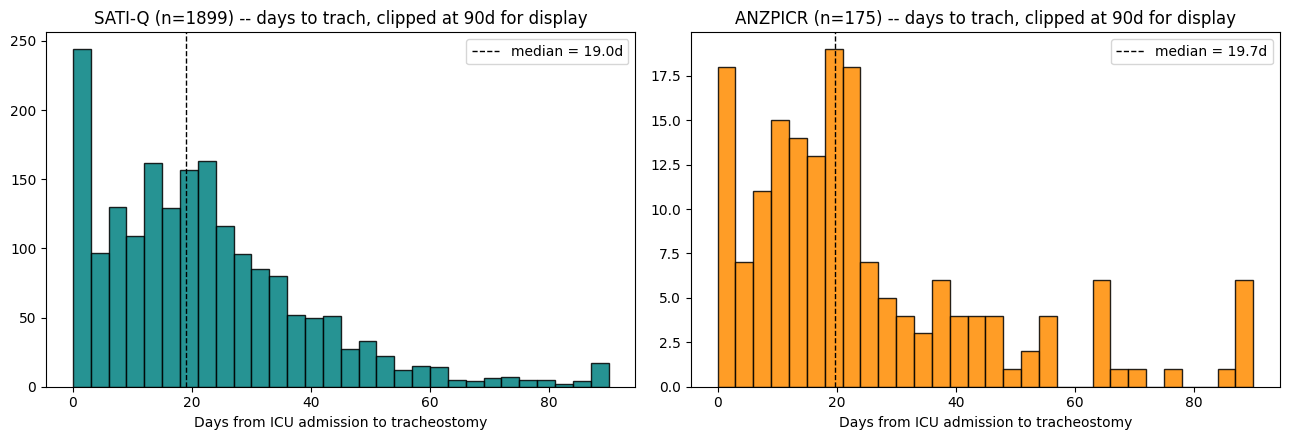

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, df, name, color in [(axes[0], s, 'SATI-Q', 'teal'), (axes[1], a, 'ANZPICR', 'darkorange')]:
    ax.hist(df['days_to_trach'].clip(upper=90), bins=30, color=color, edgecolor='black', alpha=0.85)
    ax.set_title(f'{name} (n={len(df)}) -- days to trach, clipped at 90d for display')
    ax.set_xlabel('Days from ICU admission to tracheostomy')
    ax.axvline(df['days_to_trach'].median(), color='black', linestyle='--', linewidth=1,
               label=f"median = {df['days_to_trach'].median():.1f}d")
    ax.legend()

plt.tight_layout()
plt.savefig(f'{BASE}/derived/fig_days_to_trach_hist.png', dpi=130)
plt.show()

In [14]:
desc = pd.concat([
    s['days_to_trach'].describe().rename('SATI-Q'),
    a['days_to_trach'].describe().rename('ANZPICR'),
], axis=1).round(1)
desc

,SATI-Q,ANZPICR
count,1899.0,175.0
mean,22.2,26.5
std,22.9,28.4
min,0.0,0.0
25%,9.0,10.6
50%,19.0,19.7
75%,30.0,33.2
max,427.0,250.0


The two registries land on a strikingly similar **median** timing (~19-20 days) despite very different sample sizes, countries, and eras of data collection — one of the more notable cross-registry findings in this EDA. SATI-Q has a much longer tail (max 427d vs 250d), consistent with it also capturing older children up to adulthood via `TIPO`, where ANZPICR is paediatric-only.

**Sensitivity table** — group sizes at a range of candidate early/late cutoffs (none of these is chosen yet; see RESEARCH_PROTOCOL.md's open questions):

In [15]:
rows = []
for cutoff in [3, 5, 7, 10, 14, 21]:
    rows.append({
        'cutoff_days': cutoff,
        'SATI-Q early (n)': int((s['days_to_trach'] <= cutoff).sum()),
        'SATI-Q late (n)': int((s['days_to_trach'] > cutoff).sum()),
        'ANZPICR early (n)': int((a['days_to_trach'] <= cutoff).sum()),
        'ANZPICR late (n)': int((a['days_to_trach'] > cutoff).sum()),
    })
pd.DataFrame(rows)

,cutoff_days,SATI-Q early (n),SATI-Q late (n),ANZPICR early (n),ANZPICR late (n)
0,3,264,1635,18,157
1,5,341,1558,22,153
2,7,428,1471,30,145
3,10,540,1359,39,136
4,14,742,1157,59,116
5,21,1086,813,97,78


## 5. "Cost of waiting" — device-time-dependent complications (SATI-Q)

SATI-Q's `FiCompUti` complications file lets us look directly at the price of staying intubated longer before a tracheostomy: VAP, accidental extubation, CLABSI, CAUTI, pressure ulcers. ANZPICR has no equivalent complications file in this dataset, so this section is SATI-Q only.

In [16]:
comp_cols = ['vap', 'accidental_extubation', 'clabsi', 'cauti', 'pressure_ulcer']
s2 = s.copy()
s2['days_to_trach_bin'] = pd.qcut(s2['days_to_trach'], 5, duplicates='drop')
s2['any_complication'] = s2[comp_cols].any(axis=1)

comp_by_bin = (s2.groupby('days_to_trach_bin', observed=True)[comp_cols + ['any_complication']].mean() * 100).round(1)
comp_by_bin['n'] = s2.groupby('days_to_trach_bin', observed=True).size()
comp_by_bin

,vap,accidental_extubation,clabsi,cauti,pressure_ulcer,any_complication,n
days_to_trach_bin,,,,,,,
"(-0.001, 6.0]",6.266319,2.610966,2.872063,4.699739,2.088773,13.6,383
"(6.0, 15.0]",12.5,7.0,3.5,9.25,6.5,29.5,400
"(15.0, 23.0]",19.117647,7.598039,9.558824,15.196078,9.313725,42.2,408
"(23.0, 34.0]",24.293785,12.99435,13.559322,20.621469,13.276836,54.2,354
"(34.0, 427.0]",30.225989,12.146893,20.903955,26.836158,15.819209,56.8,354


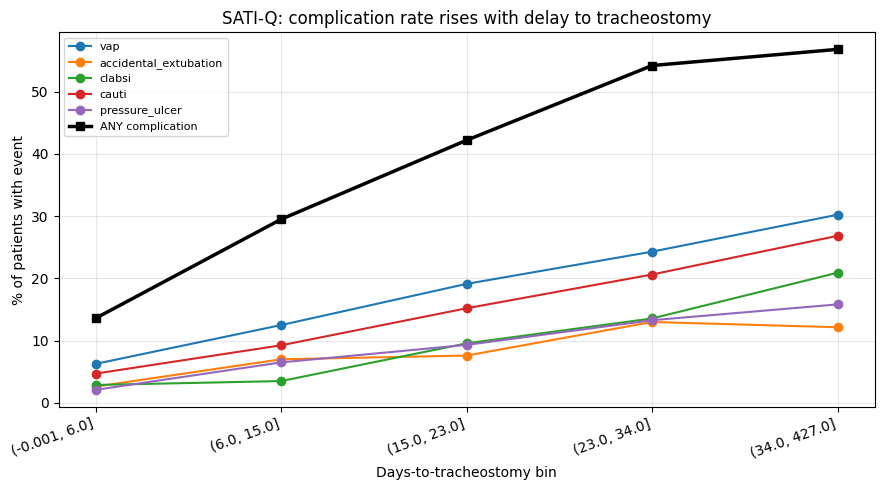

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(comp_by_bin))
labels = [str(i) for i in comp_by_bin.index]
for c in comp_cols:
    ax.plot(x, comp_by_bin[c], marker='o', label=c)
ax.plot(x, comp_by_bin['any_complication'], marker='s', linewidth=2.5, color='black', label='ANY complication')
ax.set_xticks(list(x)); ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('% of patients with event')
ax.set_xlabel('Days-to-tracheostomy bin')
ax.set_title('SATI-Q: complication rate rises with delay to tracheostomy')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE}/derived/fig_complications_by_delay.png', dpi=130)
plt.show()

**This is the clearest signal in the whole dataset**: every one of the five complication rates rises monotonically with days-to-trach, and "any complication" goes from ~14% in the earliest-trach group to ~57% in the latest. That's consistent with the "cost of waiting" framing — more ventilator/catheter/immobility time before the trach means more chances to acquire a device-associated harm.

**But is it about *waiting*, or about being *sicker*?** Kids who end up with a late trach might simply be sicker from the start, and their complications and their delayed trach could both just be downstream of that, rather than the delay itself causing the harm. Checking against admission severity:

In [18]:
print('Median admission severity_prob (%) by days-to-trach bin:')
print(s2.groupby('days_to_trach_bin', observed=True)['severity_prob'].median().round(2))
print()
corr = s2[['days_to_trach', 'severity_prob']].dropna().corr().iloc[0, 1]
print(f'Correlation(days_to_trach, admission severity_prob) = {corr:.3f}')
corr_age = s2[['days_to_trach', 'age']].dropna().corr().iloc[0, 1]
print(f'Correlation(days_to_trach, age) = {corr_age:.3f}')

Median admission severity_prob (%) by days-to-trach bin:
days_to_trach_bin
(-0.001, 6.0]    3.17
(6.0, 15.0]      3.98
(15.0, 23.0]     4.92
(23.0, 34.0]     4.70
(34.0, 427.0]    5.22
Name: severity_prob, dtype: float64

Correlation(days_to_trach, admission severity_prob) = 0.039
Correlation(days_to_trach, age) = -0.091


Admission-time severity is only weakly correlated with timing (r≈0.04) — nowhere near strong enough to explain a jump from 14% to 57% complication rate on its own. That makes a pure "sicker-kids-get-late-trachs" explanation unconvincing, and leaves cumulative device-time exposure as the more plausible mechanism — but admission severity doesn't capture how a child's condition evolved *during* the stay, so this is suggestive, not proof of causation.

## 6. "Cost of tracheostomy" — mortality & LOS by timing

> **Bias warning — read before interpreting this section.** Comparing mortality between early- and late-trach groups is subject to **immortal time bias**: a child can only be in the "late trach" group if they survived long enough to reach it, while an "early trach" child has had less time to die first. This will mechanically bias any naive comparison toward making early tracheostomy look protective. The numbers below are descriptive only — a defensible answer needs a landmark or time-varying-exposure analysis (see RESEARCH_PROTOCOL.md, stage 3), not this section.

In [19]:
print('SATI-Q: ICU mortality % and LOS (median days) by days-to-trach bin')
print(s2.groupby('days_to_trach_bin', observed=True).agg(
    n=('icu_mortality', 'size'),
    icu_mortality_pct=('icu_mortality', lambda x: round(x.mean()*100, 1)),
    los_median=('los_days', 'median'),
))

SATI-Q: ICU mortality % and LOS (median days) by days-to-trach bin
                     n  icu_mortality_pct  los_median
days_to_trach_bin                                    
(-0.001, 6.0]      383                5.2        11.0
(6.0, 15.0]        400                4.2        24.0
(15.0, 23.0]       408                6.1        36.0
(23.0, 34.0]       354                7.9        46.0
(34.0, 427.0]      354               13.6        77.0


In [20]:
a2 = a.copy()
a2['days_to_trach_bin'] = pd.qcut(a2['days_to_trach'], 3, duplicates='drop')  # fewer bins: n=175
print('ANZPICR: ICU mortality % and LOS (median days) by days-to-trach bin (tertiles, small n)')
print(a2.groupby('days_to_trach_bin', observed=True).agg(
    n=('icu_mortality', 'size'),
    icu_mortality_pct=('icu_mortality', lambda x: round(x.mean()*100, 1)),
    los_median=('los_days', 'median'),
))

ANZPICR: ICU mortality % and LOS (median days) by days-to-trach bin (tertiles, small n)
                    n  icu_mortality_pct  los_median
days_to_trach_bin                                   
(-0.001, 13.917]   58                3.4   23.335000
(13.917, 24.792]   58                5.2   47.115625
(24.792, 250.0]    59               11.9   89.741667


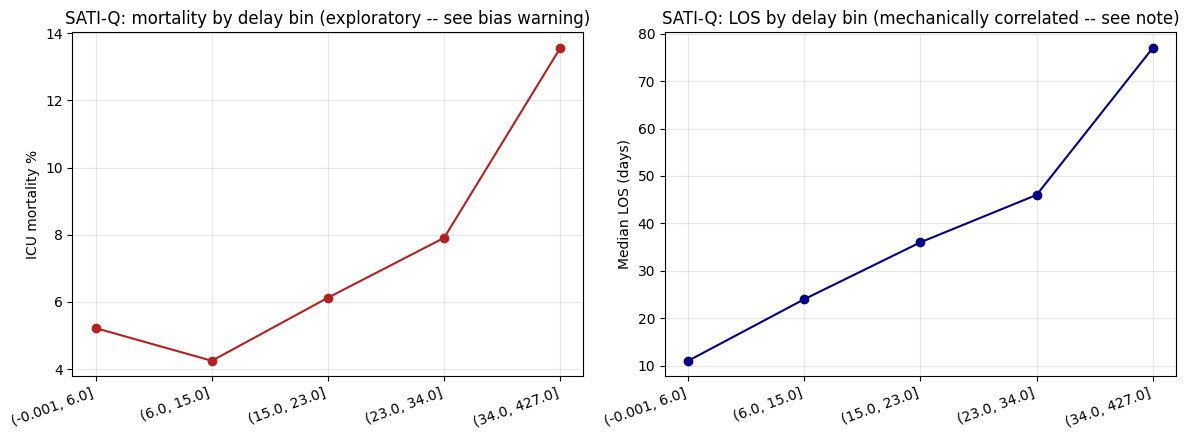

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

m = s2.groupby('days_to_trach_bin', observed=True)['icu_mortality'].mean() * 100
axes[0].plot(range(len(m)), m.values, marker='o', color='firebrick')
axes[0].set_xticks(range(len(m))); axes[0].set_xticklabels([str(i) for i in m.index], rotation=20, ha='right')
axes[0].set_ylabel('ICU mortality %'); axes[0].set_title('SATI-Q: mortality by delay bin (exploratory -- see bias warning)')
axes[0].grid(alpha=0.3)

l = s2.groupby('days_to_trach_bin', observed=True)['los_days'].median()
axes[1].plot(range(len(l)), l.values, marker='o', color='navy')
axes[1].set_xticks(range(len(l))); axes[1].set_xticklabels([str(i) for i in l.index], rotation=20, ha='right')
axes[1].set_ylabel('Median LOS (days)'); axes[1].set_title('SATI-Q: LOS by delay bin (mechanically correlated -- see note)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE}/derived/fig_mortality_los_by_delay.png', dpi=130)
plt.show()

LOS rising with days-to-trach is close to definitional (a later trach date pushed out from the same admission start mechanically extends the observed stay for everyone still in it), so it can't be read as a *consequence* of waiting the way the complication curve can. Mortality also rises across bins, but per the bias warning above, that pattern is exactly what immortal time bias predicts even under a null true effect — **this plot cannot distinguish "waiting is dangerous" from "we conditioned on surviving longer to reach the late-trach group."**

## 7. Cross-registry comparability

Before any pooling is considered: how similar are the two cohorts on the variables that matter?

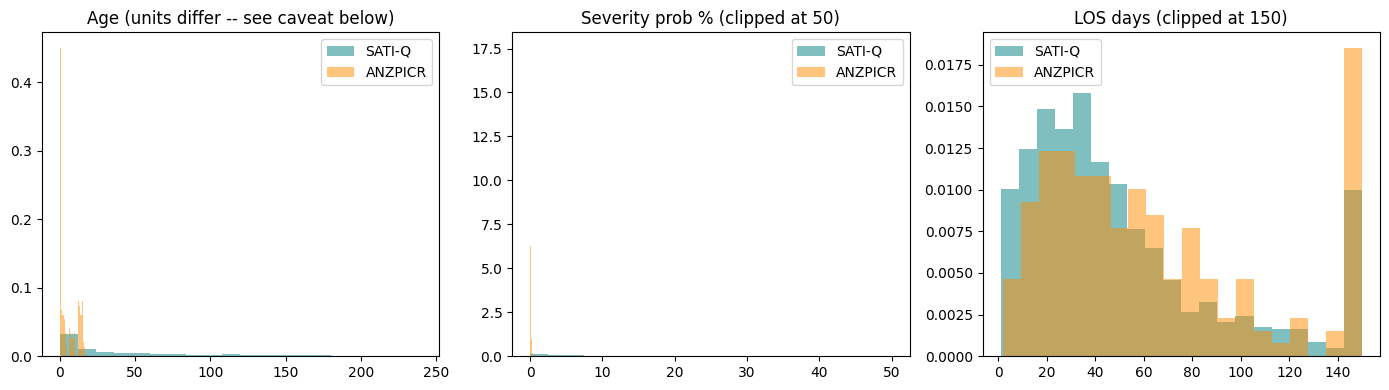

CAVEAT: SATI-Q age (EDAD) unit depends on TIPO (months/years/days) and was not
re-derived to a single unit here -- treat the age panel as approximate only.


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for df, name, color in [(s, 'SATI-Q', 'teal'), (a, 'ANZPICR', 'darkorange')]:
    axes[0].hist(df['age'].dropna(), bins=20, alpha=0.5, label=name, color=color, density=True)
    axes[1].hist(df['severity_prob'].dropna().clip(upper=50), bins=20, alpha=0.5, label=name, color=color, density=True)
    axes[2].hist(df['los_days'].dropna().clip(upper=150), bins=20, alpha=0.5, label=name, color=color, density=True)

axes[0].set_title('Age (units differ -- see caveat below)'); axes[0].legend()
axes[1].set_title('Severity prob % (clipped at 50)'); axes[1].legend()
axes[2].set_title('LOS days (clipped at 150)'); axes[2].legend()
plt.tight_layout()
plt.savefig(f'{BASE}/derived/fig_cross_registry_comparability.png', dpi=130)
plt.show()

print('CAVEAT: SATI-Q age (EDAD) unit depends on TIPO (months/years/days) and was not')
print('re-derived to a single unit here -- treat the age panel as approximate only.')

## 8. Summary

**Findings:**
- Both registries show a strikingly similar median time-to-tracheostomy (~19-20 days) despite very different sample sizes (1,899 vs 175 eligible admissions), countries, and eras.
- SATI-Q shows a strong, monotonic rise in device-associated complications (VAP, accidental extubation, CLABSI, CAUTI, pressure ulcers) with days-to-trach — from ~14% (earliest) to ~57% (latest) having at least one complication. Admission-time severity barely correlates with timing (r≈0.04), so this is unlikely to be purely explained by sicker kids simply getting delayed trachs.
- Mortality and LOS also rise with delay, but both are structurally/methodologically compromised for a causal read here (immortal time bias for mortality, near-definitional mechanics for LOS) — a landmark or time-varying-exposure model is needed before this can support any claim about timing's effect on survival.
- No ANZPICR-side complications data was available in this dataset to replicate the "cost of waiting" analysis on the second registry.

**Data-quality issues found and fixed in this pass:**
- `FiCompUti`'s 0/1 coding is the *opposite* of what the data dictionary states — confirmed empirically and corrected (also fixed in RESEARCH_PROTOCOL.md/HANDOFF.md).
- 33 SATI-Q rows had `TRAQFF` before `TRAQFI` (negative duration) — excluded.
- 8 further SATI-Q rows had a trach date beyond the recorded LOS (impossible) — excluded (this is a new check beyond the original EDA's negative-duration-only filter).
- ANZPICR's own timing field (`ADX_DHr` on diagnosis code 1506) needed `ADX_CAT`=3 filtering to isolate *new* tracheostomies from pre-existing/acute-on-admission ones — all 175 eligible rows passed the date sanity checks cleanly.

**Open methodological work before this can answer the research question:**
- Immortal-time-bias-safe analysis (landmark or Cox with trach as a time-varying covariate) — see RESEARCH_PROTOCOL.md stage 3.
- A confirmed early/late cutoff (or committing fully to the continuous/landmark approach and dropping the dichotomy).
- Investigating whether ANZPICR's diagnosis file (code 465, "Pneumonia or Pneumonitis", flagged as an ICU occurrence) can serve as a rough VAP proxy to give the second registry any "cost of waiting" signal at all — not yet attempted.